包导入，matplotlib中文支持

In [1]:
import os
import numpy as np
import scipy.signal as signal
import scipy.linalg
import matplotlib.pyplot as plt
import soundfile as sf

# matplotlib 中文支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

输入信号：wormhole.wav前1秒
卷积信号：4096采样长度的chirp，20hz~20000hz，对数扫频
目标：在已知卷积信号下，从卷积输出中反卷积出输入信号

采样率 = 48000 Hz，输入长度 n_x = 48000
卷积核长度 n_h = 4096，卷积输出长度 = 52095


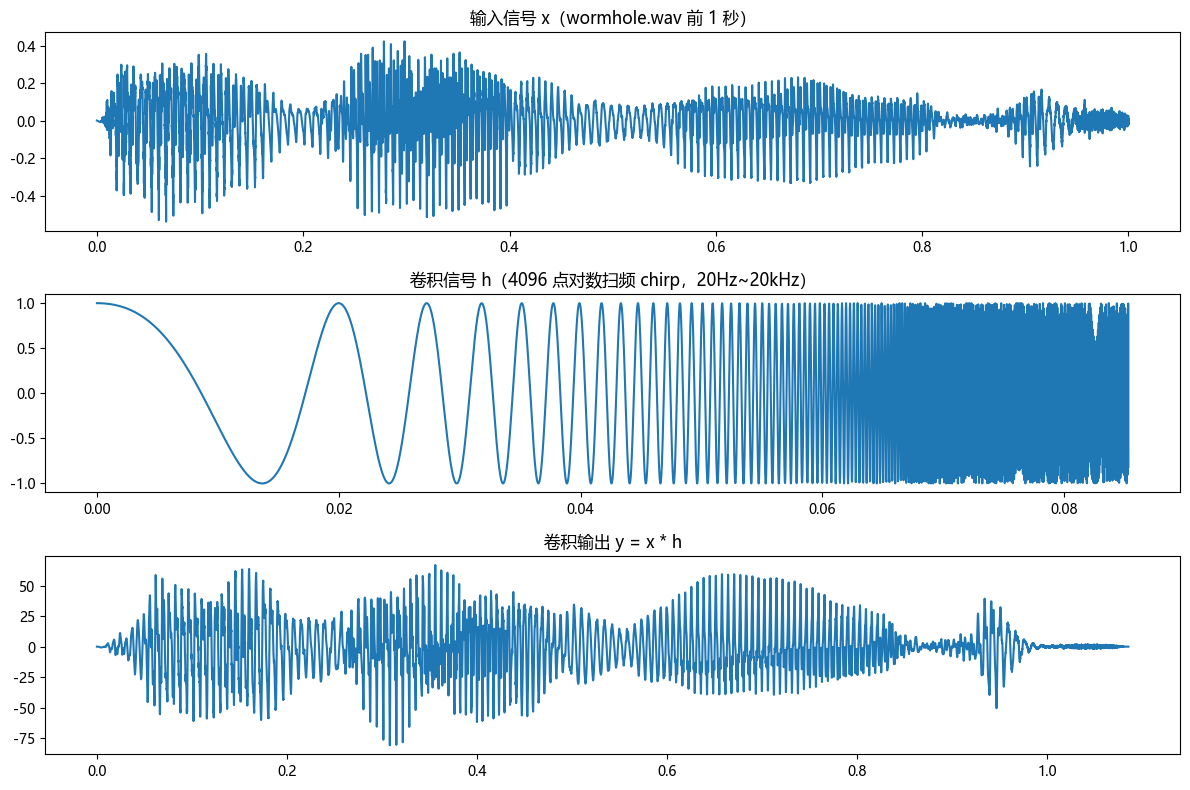

In [2]:
def snr_db(x, x_hat):
    """信噪比（dB）：SNR = 10*log10(||x||^2 / ||x - x_hat||^2)"""
    return 10 * np.log10(np.sum(x ** 2) / np.sum((x - x_hat) ** 2))


# ---- 输入信号：wormhole.wav 前 1 秒 ----
# 同时兼容「工作区根目录」与「笔记本所在目录」两种运行环境
candidates = [
    'qwqdsp/tests/work_dir/input/wormhole.wav',
    '../../tests/work_dir/input/wormhole.wav',
]
wav_path = next(p for p in candidates if os.path.exists(p))

x, sr = sf.read(wav_path)
if x.ndim > 1:
    x = x.mean(axis=1)          # 多声道取平均
x = x[:sr * 1]                  # 前 1 秒
n_x = len(x)
print(f'采样率 = {sr} Hz，输入长度 n_x = {n_x}')

# ---- 卷积信号：4096 采样长度的 chirp，20Hz ~ 20000Hz，对数扫频 ----
n_h = 4096
t_h = np.arange(n_h) / sr
h = signal.chirp(t_h, f0=20.0, t1=n_h / sr, f1=20000.0, method='logarithmic')

# ---- 卷积输出 y = x * h（线性卷积，长度 n_x + n_h - 1）----
y = np.convolve(x, h)
print(f'卷积核长度 n_h = {n_h}，卷积输出长度 = {len(y)}')

# ---- 波形预览 ----
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
axes[0].plot(np.arange(n_x) / sr, x)
axes[0].set_title('输入信号 x（wormhole.wav 前 1 秒）')
axes[1].plot(t_h, h)
axes[1].set_title('卷积信号 h（4096 点对数扫频 chirp，20Hz~20kHz）')
axes[2].plot(np.arange(len(y)) / sr, y)
axes[2].set_title('卷积输出 y = x * h')
plt.tight_layout()
plt.show()

# 1.直接频域相除
$$\hat{X}(\omega) = \frac{Y(\omega)}{H(\omega)}$$

直接频域相除：SNR = 279.18 dB


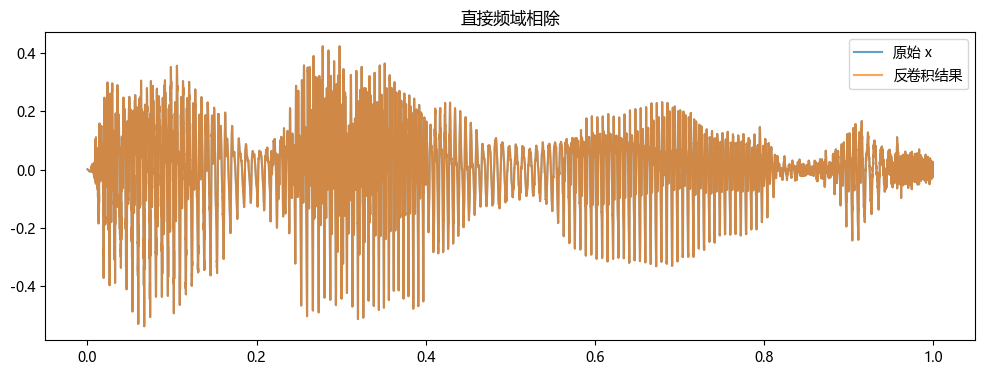

In [24]:
def deconv_direct(y, h, n_x, eps=1e-8):
    """直接频域相除：X_hat(ω) = Y(ω) / H(ω)

    nfft 取不小于 len(y) 的 2 的幂，保证线性卷积的精确可逆；
    |H| 接近 0 的频率点用阈值 eps * max|H| 保护，避免除零。
    """
    nfft = 1 << (len(y) - 1).bit_length()
    Y = np.fft.rfft(y, nfft)
    H = np.fft.rfft(h, nfft)
    thresh = eps * np.abs(H).max()
    H_safe = np.where(np.abs(H) > thresh, H, thresh)
    return np.fft.irfft(Y / H_safe, nfft)[:n_x]


x1 = deconv_direct(y, h, n_x)
print(f'直接频域相除：SNR = {snr_db(x, x1):.2f} dB')

plt.figure(figsize=(12, 4))
plt.plot(np.arange(n_x) / sr, x, label='原始 x', alpha=0.7)
plt.plot(np.arange(n_x) / sr, x1, label='反卷积结果', alpha=0.7)
plt.legend()
plt.title('直接频域相除')
plt.show()

# 2.维纳滤波
$$\hat{X}(\omega) = \left( \frac{H^*(\omega)}{\vert{}H(\omega)\vert{}^2 + K} \right) Y(\omega)$$

维纳滤波：SNR = 139.63 dB


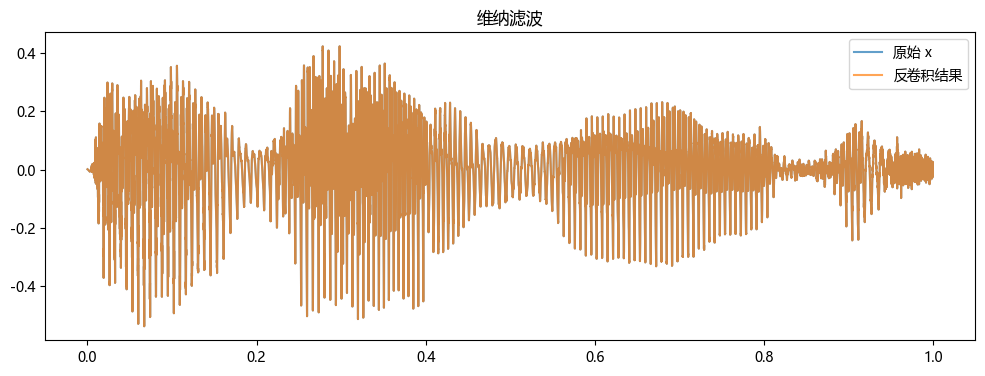

In [4]:
def deconv_wiener(y, h, n_x, K=1e-3):
    """维纳滤波：X_hat(ω) = conj(H) / (|H|^2 + K) * Y(ω)

    K 为正则化常数，防止 |H| 接近 0 时放大噪声。
    """
    nfft = 1 << (len(y) - 1).bit_length()
    Y = np.fft.rfft(y, nfft)
    H = np.fft.rfft(h, nfft)
    G = np.conj(H) / (np.abs(H) ** 2 + K)
    return np.fft.irfft(G * Y, nfft)[:n_x]


x2 = deconv_wiener(y, h, n_x)
print(f'维纳滤波：SNR = {snr_db(x, x2):.2f} dB')

plt.figure(figsize=(12, 4))
plt.plot(np.arange(n_x) / sr, x, label='原始 x', alpha=0.7)
plt.plot(np.arange(n_x) / sr, x2, label='反卷积结果', alpha=0.7)
plt.legend()
plt.title('维纳滤波')
plt.show()

# 3.时域构造核矩阵，用最小二乘法求解
其中 $A$ 是一个由卷积核 $h$ 构造的Toeplitz 矩阵（或环形矩阵/Circulant Matrix）。如果我们使用无约束的普通最小二乘法（Ordinary Least Squares, OLS）求解，目标是最小化残差：$$\min_x \Vert{}Ax - y\Vert{}_2^2$$求导令梯度为 0，得到标准解：$$\hat{x} = (A^T A)^{-1} A^T y$$

最小二乘（前 2400 点）：SNR = 268.80 dB


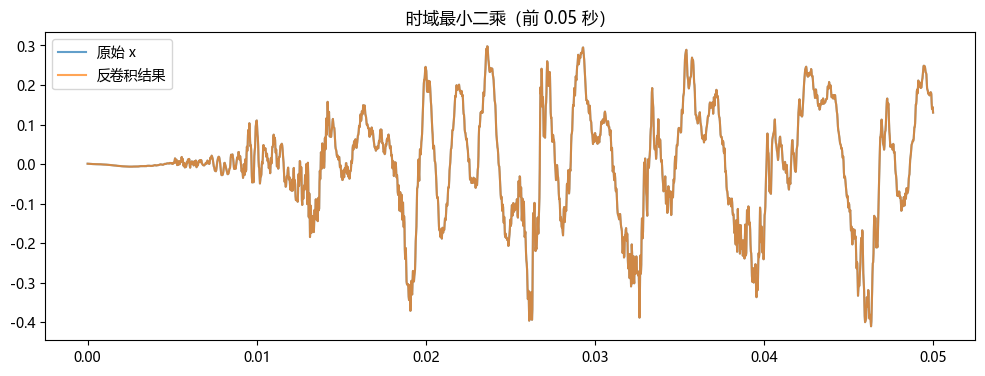

In [6]:
# 时域方法需要构造尺寸为 len(y) × n_x 的卷积矩阵 A。
# 对 1 秒信号（约 4.8 万采样）该矩阵约 18 GB，内存不可行，
# 因此这里只取前 0.05 秒的小段做演示。
seg = int(0.05 * sr)          # 2400 个采样
x_seg = x[:seg]
# 注意：y_seg 必须由 x_seg 重新卷积得到，不能直接从全长 y 里切片，
# 否则前 seg+n_h-1 个输出会混入 x_seg 之后采样的贡献。
y_seg = np.convolve(x_seg, h)


def conv_matrix(h, n_y, n_x):
    """由卷积核 h 构造 Toeplitz 卷积矩阵 A（尺寸 n_y × n_x），A[i, k] = h[i - k]"""
    c = np.concatenate([h, np.zeros(n_y - len(h))])   # 第一列：h 后补 0
    r = np.concatenate([[h[0]], np.zeros(n_x - 1)])   # 第一行：h[0] 后补 0
    return scipy.linalg.toeplitz(c, r)


def deconv_ols(y, h, n_x):
    """普通最小二乘（OLS）：x_hat = (A^T A)^{-1} A^T y，最小化 ||Ax - y||^2"""
    A = conv_matrix(h, len(y), n_x)
    x_hat, *_ = np.linalg.lstsq(A, y, rcond=None)
    return x_hat


x3 = deconv_ols(y_seg, h, seg)
print(f'最小二乘（前 {seg} 点）：SNR = {snr_db(x_seg, x3):.2f} dB')

t_seg = np.arange(seg) / sr
plt.figure(figsize=(12, 4))
plt.plot(t_seg, x_seg, label='原始 x', alpha=0.7)
plt.plot(t_seg, x3, label='反卷积结果', alpha=0.7)
plt.legend()
plt.title('时域最小二乘（前 0.05 秒）')
plt.show()

# 4.岭回归 / Tikhonov 正则化（L2 正则化）
为了解决 $A^T A$ 不可逆和病态问题，在目标函数中加入 $L2$ 惩罚项：$$\min_x \Vert{}Ax - y\Vert{}_2^2 + \lambda \Vert{}x\Vert{}_2^2$$解析解变为：$$\hat{x} = (A^T A + \lambda I)^{-1} A^T y$$

岭回归（前 2400 点）：SNR = 116.01 dB


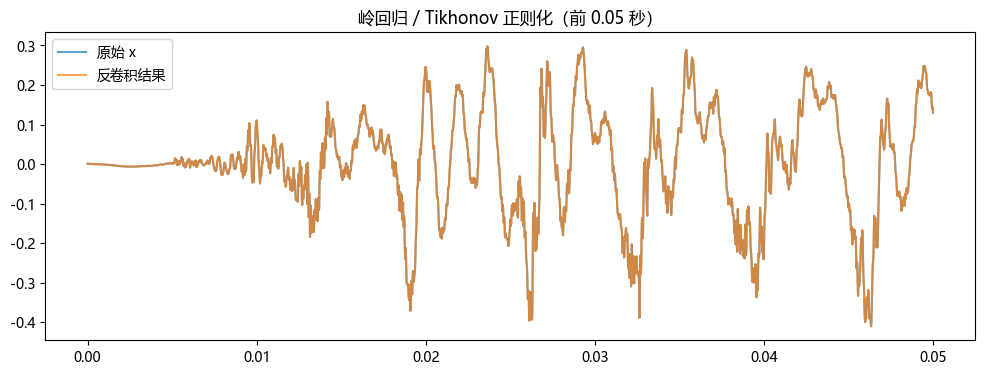

In [7]:
def deconv_ridge(y, h, n_x, lam=1e-2):
    """岭回归 / Tikhonov 正则化：x_hat = (A^T A + λI)^{-1} A^T y

    相比 OLS，加入 λ||x||^2 惩罚项，改善 A^T A 病态问题。
    """
    A = conv_matrix(h, len(y), n_x)
    ATA = A.T @ A
    return np.linalg.solve(ATA + lam * np.eye(n_x), A.T @ y)


x4 = deconv_ridge(y_seg, h, seg, lam=1e-2)
print(f'岭回归（前 {seg} 点）：SNR = {snr_db(x_seg, x4):.2f} dB')

plt.figure(figsize=(12, 4))
plt.plot(t_seg, x_seg, label='原始 x', alpha=0.7)
plt.plot(t_seg, x4, label='反卷积结果', alpha=0.7)
plt.legend()
plt.title('岭回归 / Tikhonov 正则化（前 0.05 秒）')
plt.show()

方法                  SNR (dB)
--------------------------------
直接频域相除                279.18
维纳滤波                  139.63
最小二乘 OLS              268.80
岭回归                   116.01


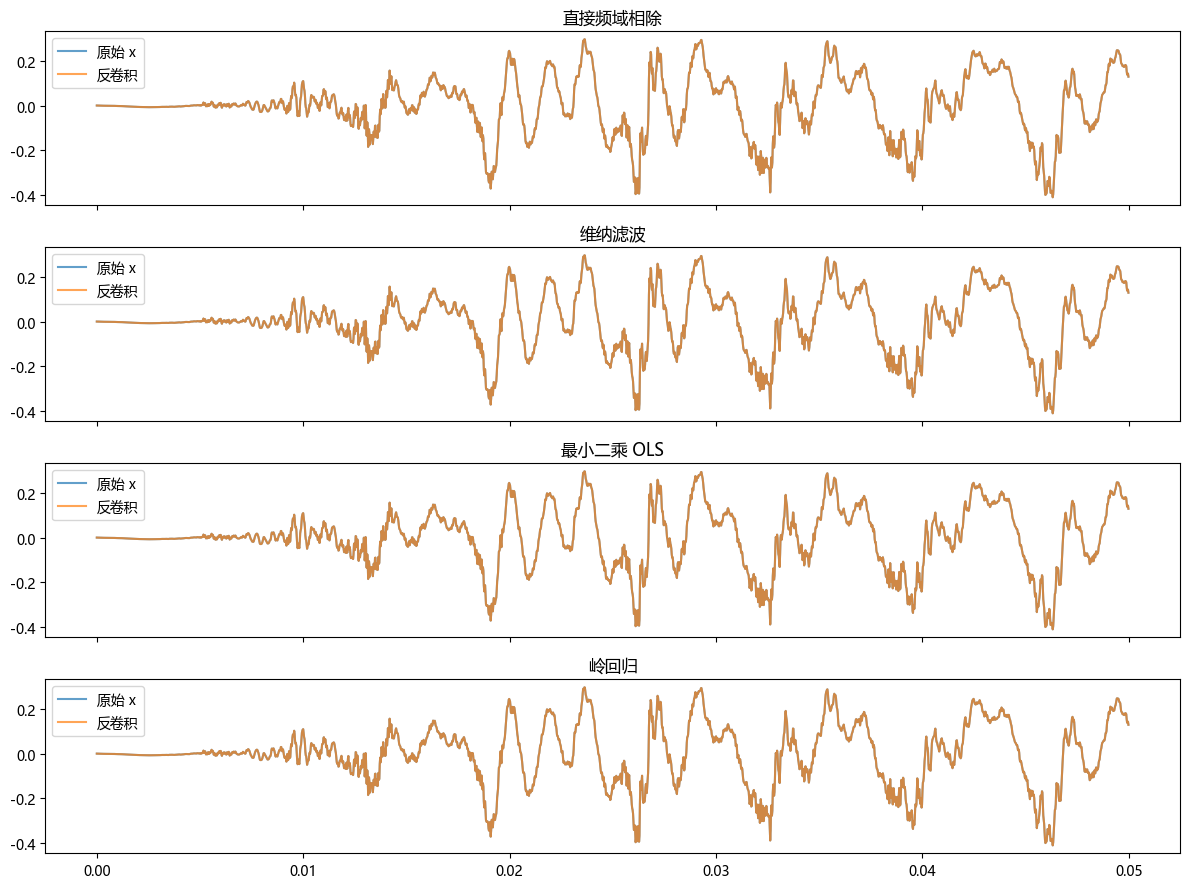

In [8]:
# ---- 各方法 SNR 汇总 ----
rows = [
    ('直接频域相除', snr_db(x, x1)),
    ('维纳滤波', snr_db(x, x2)),
    ('最小二乘 OLS', snr_db(x_seg, x3)),
    ('岭回归', snr_db(x_seg, x4)),
]
print('方法                  SNR (dB)')
print('-' * 32)
for name, snr in rows:
    print(f'{name:<18}{snr:>10.2f}')

# ---- 前 0.05 秒波形对比 ----
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
for ax, (x_hat, title) in zip(axes, [
        (x1[:seg], '直接频域相除'),
        (x2[:seg], '维纳滤波'),
        (x3, '最小二乘 OLS'),
        (x4, '岭回归')]):
    ax.plot(t_seg, x_seg, label='原始 x', alpha=0.7)
    ax.plot(t_seg, x_hat, label='反卷积', alpha=0.7)
    ax.legend()
    ax.set_title(title)
plt.tight_layout()
plt.show()

In [11]:
# !!! agent禁止运行此单元格 !!!
from IPython.display import Audio, display
display(Audio(x, rate=sr))
display(Audio(y, rate=sr))
display(Audio(x1, rate=sr))
display(Audio(x2, rate=sr))
display(Audio(x3, rate=sr))
display(Audio(x4, rate=sr))

# 5. 在卷积输出上添加噪声
实际系统中卷积输出总是混有噪声：$y = x * h + n$。
这里给卷积输出添加高斯白噪声（SNR = 40 dB），对比各反卷积方法的抗噪表现。

注意：对数扫频 chirp 的频谱随频率衰减，直接相除会把高频噪声大幅放大；
维纳滤波的 $K$、岭回归的 $\lambda$ 需相对频谱/矩阵尺度归一化才有意义。

卷积输出带噪 SNR = 39.98 dB


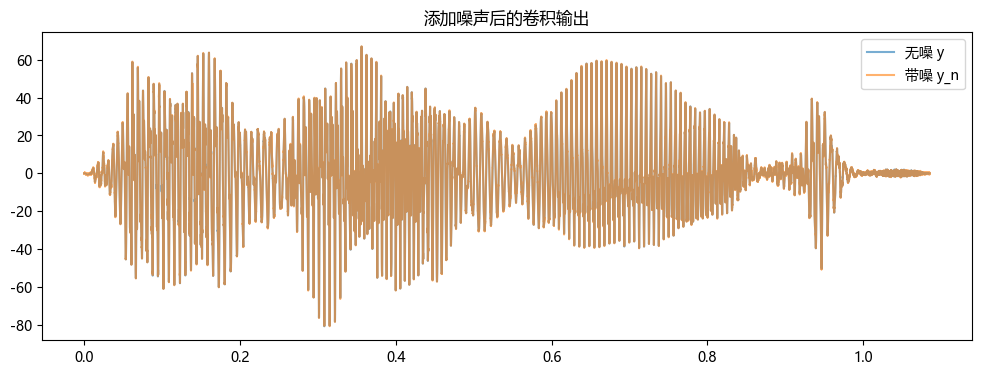

In [18]:
def add_noise(sig, snr_target=40.0, seed=42):
    """给信号添加高斯白噪声，使带噪信号 SNR 达到 snr_target (dB)"""
    rng = np.random.default_rng(seed)
    p_sig = np.mean(sig ** 2)
    p_noise = p_sig / (10 ** (snr_target / 10))
    noise = rng.normal(0.0, np.sqrt(p_noise), sig.shape)
    return sig + noise, noise


y_n, n_full = add_noise(y, 40.0)         # 全长卷积输出
y_seg_n, n_seg = add_noise(y_seg, 40.0)  # 时域方法所用小段
print(f'卷积输出带噪 SNR = {snr_db(y, y_n):.2f} dB')

plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(y)) / sr, y, label='无噪 y', alpha=0.6)
plt.plot(np.arange(len(y)) / sr, y_n, label='带噪 y_n', alpha=0.6)
plt.legend()
plt.title('添加噪声后的卷积输出')
plt.show()

In [19]:
# ---- 各方法在带噪输出上的反卷积 ----
# 直接相除 / OLS 不加正则化；维纳 K、岭回归 λ 相对频谱/矩阵尺度归一化
nfft = 1 << (len(y_n) - 1).bit_length()
K = 0.1 * np.mean(np.abs(np.fft.rfft(h, nfft)) ** 2)

A4 = conv_matrix(h, len(y_seg_n), seg)
lam = 0.01 * np.trace(A4.T @ A4) / seg

x1n = deconv_direct(y_n, h, n_x)
x2n = deconv_wiener(y_n, h, n_x, K=K)
x3n = deconv_ols(y_seg_n, h, seg)
x4n = deconv_ridge(y_seg_n, h, seg, lam=lam)

print('带噪反卷积 SNR (dB)：')
print('-' * 32)
for name, snr in [
        ('直接频域相除', snr_db(x, x1n)),
        ('维纳滤波', snr_db(x, x2n)),
        ('最小二乘 OLS', snr_db(x_seg, x3n)),
        ('岭回归', snr_db(x_seg, x4n))]:
    print(f'{name:<18}{snr:>10.2f}')

带噪反卷积 SNR (dB)：
--------------------------------
直接频域相除                  9.26
维纳滤波                   26.61
最小二乘 OLS               13.37
岭回归                    25.16


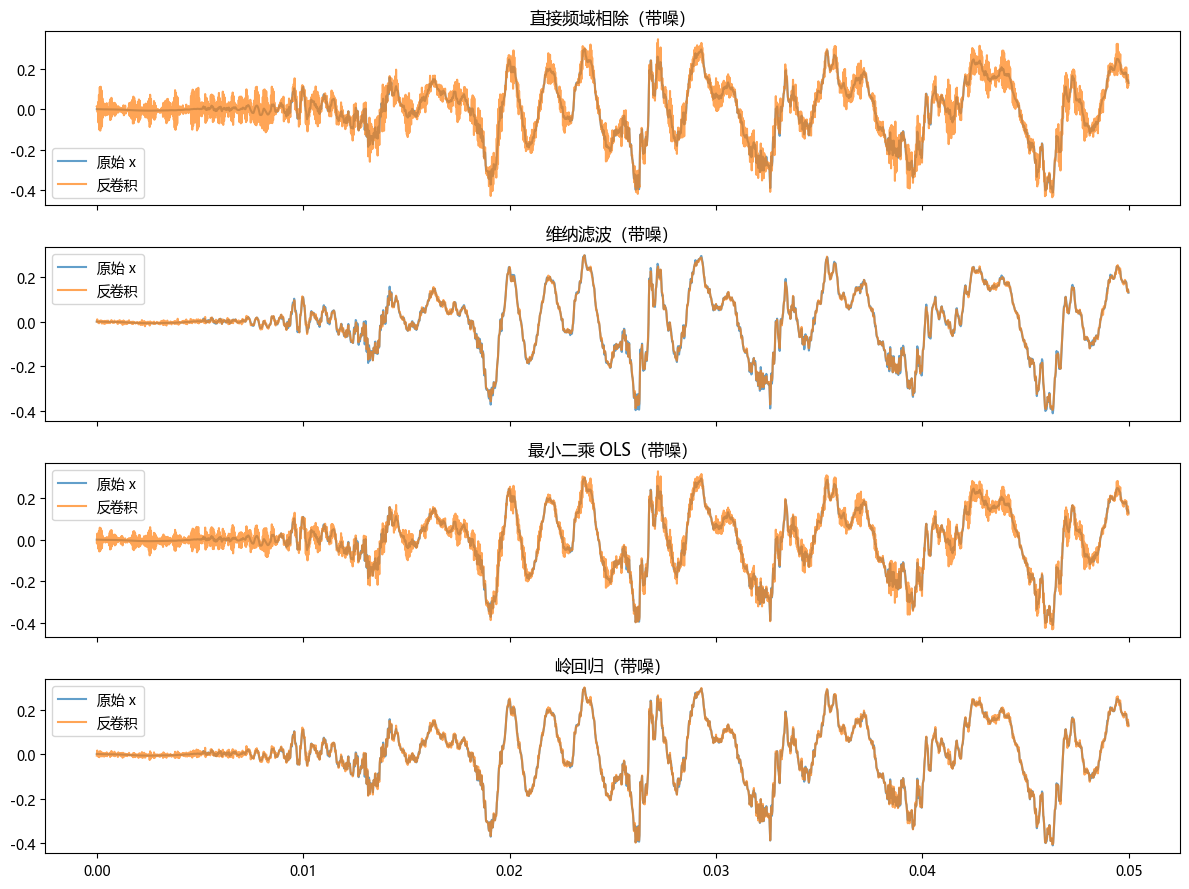

In [20]:
# ---- 带噪场景波形对比（前 0.05 秒） ----
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
for ax, (x_hat, title) in zip(axes, [
        (x1n[:seg], '直接频域相除（带噪）'),
        (x2n[:seg], '维纳滤波（带噪）'),
        (x3n, '最小二乘 OLS（带噪）'),
        (x4n, '岭回归（带噪）')]):
    ax.plot(t_seg, x_seg, label='原始 x', alpha=0.7)
    ax.plot(t_seg, x_hat, label='反卷积', alpha=0.7)
    ax.legend()
    ax.set_title(title)
plt.tight_layout()
plt.show()

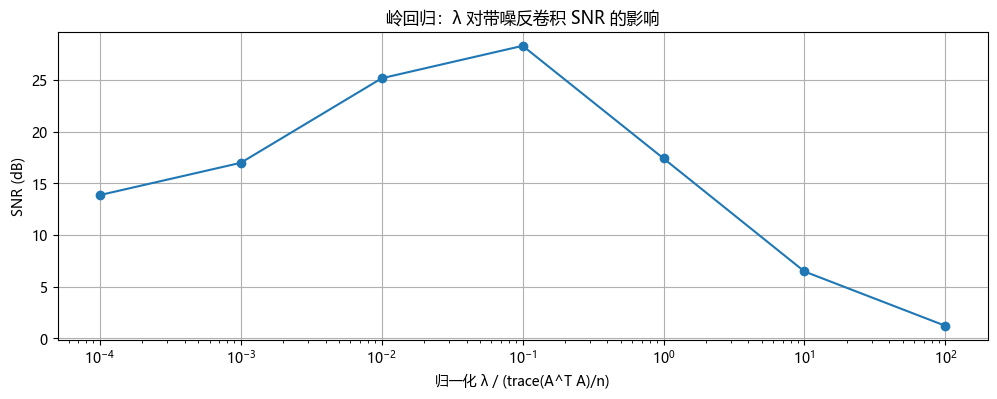

最优归一化 λ = 1.00e-01，SNR = 28.30 dB


In [22]:
# ---- 岭回归 λ 扫描：正则化强度对带噪反卷积的影响 ----
# λ 以 trace(A^T A)/n 为单位归一化，横轴展示归一化倍数
A4 = conv_matrix(h, len(y_seg_n), seg)
scale = np.trace(A4.T @ A4) / seg

lams = np.logspace(-4, 2, 7)
snrs = [snr_db(x_seg, deconv_ridge(y_seg_n, h, seg, lam * scale)) for lam in lams]

plt.figure(figsize=(12, 4))
plt.semilogx(lams, snrs, 'o-')
plt.xlabel('归一化 λ / (trace(A^T A)/n)')
plt.ylabel('SNR (dB)')
plt.title('岭回归：λ 对带噪反卷积 SNR 的影响')
plt.grid(True)
plt.show()

best = int(np.argmax(snrs))
print(f'最优归一化 λ = {lams[best]:.2e}，SNR = {snrs[best]:.2f} dB')

In [23]:
# !!! agent禁止运行此单元格 !!!
from IPython.display import Audio, display
display(Audio(x, rate=sr))
display(Audio(y_n, rate=sr))
display(Audio(x1n, rate=sr))
display(Audio(x2n, rate=sr))
display(Audio(x3n, rate=sr))
display(Audio(x4n, rate=sr))